In [1]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, Qwen2_5_VLProcessor
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

In [2]:
# TEST 1: Activation map on samples from cholecseg
# cseg_img_path = 'data/cholecseg8k/preprocessed/video01_00080/images/frame_000001.png'
# rgb_img = Image.open(cseg_img_path).convert("RGB")

hpn_img_path = '../data/hypernerf/chickchicken/rgb/2x/000047.png'
rgb_img = Image.open(hpn_img_path).convert("RGB")

model_path = '/home/tumai/models/Qwen--Qwen2.5-VL-7B-Instruct'

# patch_size, spatial_merge = 14, 2 # hyperparams -> cannot be set without re-trainig, fixed in model architecture

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(model_path, dtype=torch.bfloat16, device_map="auto")
processor = Qwen2_5_VLProcessor.from_pretrained(model_path)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [3]:
print(model)

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLU()

In [4]:
input_size = 896
def square_crop_image(image: Image.Image, xslide=0, yslide=0):
    side_length = min(image.width, image.height)
    wm, hm, rd = image.width // 2, image.height // 2, side_length // 2
    return image.crop((wm - rd - xslide, hm - rd - yslide, wm + rd - xslide, hm + rd - yslide))
cropped_image = square_crop_image(rgb_img, yslide=100).resize((input_size, input_size), Image.Resampling.LANCZOS)

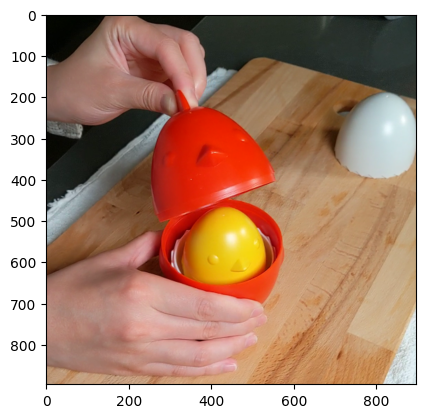

In [5]:
plt.imshow(cropped_image)
plt.show()

In [6]:
def qwen_encode_image(image: Image.Image):
    image_inputs = processor.image_processor( #type:ignore
        images=[image], return_tensors="pt"
    )
    pixel_values = image_inputs["pixel_values"].to(model.device).to(torch.bfloat16)
    image_grid_thw = image_inputs["image_grid_thw"].to(model.device)
    with torch.no_grad():
        return model.visual(pixel_values, image_grid_thw)

patch_size, spatial_merge = 14, 2
def patches_to_2d(patch_features: torch.Tensor, src_image: Image.Image):
    effective_patch_size = patch_size * spatial_merge
    patches_width, patches_height = src_image.width // effective_patch_size, src_image.height // effective_patch_size
    return patch_features.reshape(patches_height, patches_width, -1)

def patches_to_2d_dynamic(patch_features, src_image):
    """
    Convert patch features to 2D spatial layout - fully dynamic version.
    No need for patch_size or spatial_merge parameters.
    """
    num_patches = patch_features.shape[0]
    
    # Find the best spatial grid dimensions that match the image aspect ratio
    import math
    aspect_ratio = src_image.width / src_image.height
    
    # Find all possible factor pairs
    factors = []
    for i in range(1, int(math.sqrt(num_patches)) + 1):
        if num_patches % i == 0:
            factors.append((i, num_patches // i))
    
    # Choose dimensions that best match the image aspect ratio
    best_h, best_w = None, None
    min_diff = float('inf')
    
    for h, w in factors:
        grid_aspect_ratio = w / h
        diff = abs(aspect_ratio - grid_aspect_ratio)
        if diff < min_diff:
            min_diff = diff
            best_h, best_w = h, w
    
    print(f"Image aspect ratio: {aspect_ratio:.3f}")
    print(f"Grid aspect ratio: {best_w/best_h:.3f}")
    print(f"Reshaping {num_patches} patches to {best_h}x{best_w}")
    
    return patch_features.reshape(best_h, best_w, -1)

In [11]:
patch_features = qwen_encode_image(cropped_image)
print(patch_features.shape)
pca = PCA(n_components=3)
patch_features_pca = pca.fit_transform(patch_features.cpu().to(torch.float16).numpy())
scaler = MinMaxScaler(); patch_features_pca = scaler.fit_transform(patch_features_pca)
print(patch_features_pca.shape)
patch_features_pca_2d = patches_to_2d(patch_features_pca, cropped_image)

torch.Size([1024, 3584])
(1024, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


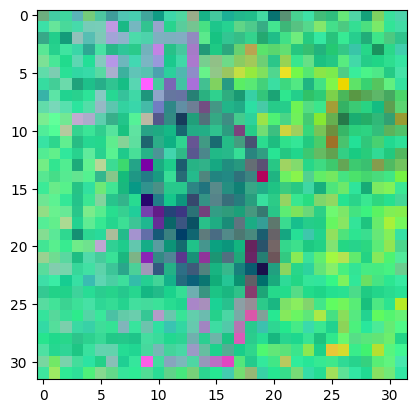

: 

In [ ]:
plt.imshow(patch_features_pca_2d)
plt.show()

In [ ]:
def qwen_encode_image(image: Image.Image):
    image_inputs = processor.image_processor( #type:ignore
        images=[image], return_tensors="pt"
    )
    pixel_values = image_inputs["pixel_values"].to(model.device).to(torch.bfloat16)
    image_grid_thw = image_inputs["image_grid_thw"].to(model.device)
    with torch.no_grad():
        return model.visual(pixel_values, image_grid_thw)

def patches_to_2d(patch_features: torch.Tensor, src_image: Image.Image):
    """
    Convert patch features to 2D spatial layout.
    Note: Qwen's vision encoder may not produce exactly the expected number of patches
    due to its internal processing. We need to handle this gracefully.
    """
    effective_patch_size = patch_size * spatial_merge
    patches_width, patches_height = src_image.width // effective_patch_size, src_image.height // effective_patch_size
    expected_patches = patches_height * patches_width
    
    print(f"Expected patches: {patches_height} x {patches_width} = {expected_patches}")
    print(f"Actual patches: {patch_features.shape[0]}")
    
    if patch_features.shape[0] != expected_patches:
        print(f"Warning: Patch count mismatch! Expected {expected_patches}, got {patch_features.shape[0]}")
        # For now, we'll pad or truncate to match expected dimensions
        if patch_features.shape[0] > expected_patches:
            # Truncate excess patches
            patch_features = patch_features[:expected_patches]
        else:
            # Pad with zeros
            padding_size = expected_patches - patch_features.shape[0]
            padding = torch.zeros(padding_size, patch_features.shape[1], dtype=patch_features.dtype, device=patch_features.device)
            patch_features = torch.cat([patch_features, padding], dim=0)
    
    return patch_features.reshape(patches_height, patches_width, -1)

In [ ]:
# Extract vision features
patch_features = qwen_encode_image(rgb_img)
print(f"patch_features shape: {patch_features.shape}")
print(f"Image dimensions: {rgb_img.size} (width x height)")

# Convert to 2D spatial layout
patch_features_2d = patches_to_2d(patch_features, rgb_img)
print(f"patch_features_2d shape: {patch_features_2d.shape}")
# patch_features_2d shape [image.height // effective_patch_size, image.width // effective_patch_size, 3584]

In [ ]:
# Apply PCA to reduce dimensionality for visualization
pca = PCA(n_components=3)
patch_features_pca = pca.fit_transform(patch_features.cpu().to(torch.float16).numpy())
scaler = MinMaxScaler()
patch_features_pca = scaler.fit_transform(patch_features_pca)

# Convert PCA features to 2D spatial layout
patch_features_pca_2d = patches_to_2d(torch.tensor(patch_features_pca), rgb_img)

# Understanding Vision-Language Models: Concepts and Testing

## What are Vision Patches?

Vision Transformers (ViTs) like Qwen2.5-VL work by:

1. **Image Patches**: The input image is divided into small patches (typically 14x14 or 16x16 pixels)
2. **Patch Embeddings**: Each patch is converted to a high-dimensional vector (embedding)
3. **Spatial Relationships**: The model learns spatial relationships between patches through attention mechanisms
4. **Feature Extraction**: The final layer produces rich feature representations for each patch

## What Should We Expect?

- **Object Segmentation**: Patches containing objects should have similar feature vectors
- **Spatial Coherence**: Adjacent patches with similar content should have similar features
- **Semantic Understanding**: The model should encode semantic information (e.g., "this patch contains surgical instruments")

## Testing Strategy

1. **Feature Visualization**: Use PCA to reduce high-dimensional features to 3D for visualization
2. **Spatial Analysis**: Check if features form coherent spatial regions
3. **Language-Vision Alignment**: Test how well the model connects visual features to language descriptions


In [ ]:
# Enhanced debugging and visualization functions

def analyze_vision_encoder(model, processor, image):
    """Analyze the vision encoder to understand patch extraction"""
    print("=== VISION ENCODER ANALYSIS ===")
    
    # Get image inputs
    image_inputs = processor.image_processor(images=[image], return_tensors="pt")
    pixel_values = image_inputs["pixel_values"]
    image_grid_thw = image_inputs["image_grid_thw"]
    
    print(f"Image size: {image.size}")
    print(f"Pixel values shape: {pixel_values.shape}")
    print(f"Image grid THW: {image_grid_thw}")
    
    # Analyze the patch embedding layer
    patch_embed = model.visual.patch_embed
    print(f"\nPatch embedding layer:")
    print(f"  - Conv3d kernel size: {patch_embed.proj.kernel_size}")
    print(f"  - Conv3d stride: {patch_embed.proj.stride}")
    print(f"  - Input channels: {patch_embed.proj.in_channels}")
    print(f"  - Output channels: {patch_embed.proj.out_channels}")
    
    # Calculate expected patch dimensions
    kernel_h, kernel_w = patch_embed.proj.kernel_size[1], patch_embed.proj.kernel_size[2]
    stride_h, stride_w = patch_embed.proj.stride[1], patch_embed.proj.stride[2]
    
    expected_patches_h = (image.height - kernel_h) // stride_h + 1
    expected_patches_w = (image.width - kernel_w) // stride_w + 1
    expected_total_patches = expected_patches_h * expected_patches_w
    
    print(f"\nExpected patch grid:")
    print(f"  - Patch size: {kernel_h}x{kernel_w}")
    print(f"  - Stride: {stride_h}x{stride_w}")
    print(f"  - Grid: {expected_patches_h}x{expected_patches_w} = {expected_total_patches} patches")
    
    return expected_patches_h, expected_patches_w, expected_total_patches

def create_fine_grained_visualization(patch_features_2d, original_image, title="Feature Visualization"):
    """Create a more detailed visualization with multiple views"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(title, fontsize=16)
    
    # Original image
    axes[0, 0].imshow(original_image)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis('off')
    
    # PCA visualization (RGB)
    if patch_features_2d.shape[-1] == 3:
        axes[0, 1].imshow(patch_features_2d)
        axes[0, 1].set_title("PCA Features (RGB)")
        axes[0, 1].axis('off')
    
    # Individual PCA components
    for i in range(min(3, patch_features_2d.shape[-1])):
        row = 1 if i < 3 else 0
        col = i if i < 3 else i - 3
        if row < 2 and col < 3:
            im = axes[row, col].imshow(patch_features_2d[:, :, i], cmap='viridis')
            axes[row, col].set_title(f"PCA Component {i+1}")
            axes[row, col].axis('off')
            plt.colorbar(im, ax=axes[row, col])
    
    # Feature statistics
    axes[1, 2].text(0.1, 0.8, f"Feature shape: {patch_features_2d.shape}", transform=axes[1, 2].transAxes)
    axes[1, 2].text(0.1, 0.6, f"Mean: {patch_features_2d.mean():.3f}", transform=axes[1, 2].transAxes)
    axes[1, 2].text(0.1, 0.4, f"Std: {patch_features_2d.std():.3f}", transform=axes[1, 2].transAxes)
    axes[1, 2].text(0.1, 0.2, f"Min: {patch_features_2d.min():.3f}", transform=axes[1, 2].transAxes)
    axes[1, 2].text(0.1, 0.0, f"Max: {patch_features_2d.max():.3f}", transform=axes[1, 2].transAxes)
    axes[1, 2].set_title("Feature Statistics")
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def test_language_vision_alignment(model, processor, image, queries):
    """Test how well the model connects visual features to language"""
    print("=== LANGUAGE-VISION ALIGNMENT TEST ===")
    
    for query in queries:
        print(f"\nQuery: '{query}'")
        
        # Create a prompt
        prompt = f"<|im_start|>user\n<|image_pad|>Describe what you see in this medical image, focusing on {query}.<|im_end|>\n<|im_start|>assistant\n"
        
        # Process the input
        inputs = processor(text=prompt, images=[image], return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        
        # Generate response
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=100,
                do_sample=True,
                temperature=0.7,
                pad_token_id=processor.tokenizer.eos_token_id
            )
        
        # Decode response
        response = processor.decode(outputs[0], skip_special_tokens=True)
        response = response.split("assistant\n")[-1].strip()
        print(f"Response: {response}")
        
        return response


In [ ]:
# COMPREHENSIVE TESTING: Understanding Qwen2.5-VL Performance

# Step 1: Analyze the vision encoder architecture
print("=== STEP 1: VISION ENCODER ANALYSIS ===")
expected_h, expected_w, expected_total = analyze_vision_encoder(model, processor, rgb_img)

# Step 2: Extract and analyze features
print("\n=== STEP 2: FEATURE EXTRACTION ===")
patch_features = qwen_encode_image(rgb_img)
print(f"Actual patch features shape: {patch_features.shape}")
print(f"Expected vs Actual: {expected_total} vs {patch_features.shape[0]}")

# Step 3: Create better 2D visualization
print("\n=== STEP 3: SPATIAL VISUALIZATION ===")
# Use the correct dimensions from the encoder analysis
patch_features_2d = patch_features.reshape(expected_h, expected_w, -1)
print(f"2D features shape: {patch_features_2d.shape}")

# Step 4: Apply PCA for visualization
print("\n=== STEP 4: PCA VISUALIZATION ===")
pca = PCA(n_components=3)
patch_features_pca = pca.fit_transform(patch_features.cpu().numpy())
scaler = MinMaxScaler()
patch_features_pca = scaler.fit_transform(patch_features_pca)

# Reshape PCA features to 2D
patch_features_pca_2d = patch_features_pca.reshape(expected_h, expected_w, 3)
print(f"PCA features shape: {patch_features_pca_2d.shape}")

# Step 5: Create comprehensive visualization
create_fine_grained_visualization(patch_features_pca_2d, rgb_img, "Qwen2.5-VL Feature Analysis")


In [ ]:
plt.imshow(patch_features_pca_2d)
plt.show()

In [ ]:
# TEST 2: Query-based activation map (vocabulary based)

In [ ]:
# TEST 3: Qwen video processor for temporal analysis

In [ ]:
# TEST 4: 3D graph integration (how to measure? Create tests with depth / z-coordinate checks)

In [ ]:
# DEBUGGING: Understanding the Vision Encoder Architecture

def debug_vision_encoder_detailed(model, processor, image):
    """Detailed analysis of the vision encoder to understand the actual architecture"""
    print("=== DETAILED VISION ENCODER DEBUGGING ===")
    
    # Get image inputs
    image_inputs = processor.image_processor(images=[image], return_tensors="pt")
    pixel_values = image_inputs["pixel_values"]
    image_grid_thw = image_inputs["image_grid_thw"]
    
    print(f"Image size: {image.size}")
    print(f"Pixel values shape: {pixel_values.shape}")
    print(f"Image grid THW: {image_grid_thw}")
    
    # The key insight: Qwen2.5-VL uses a 3D convolution with temporal dimension
    # Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14))
    # This means: 2 temporal frames, 14x14 spatial patches
    
    patch_embed = model.visual.patch_embed
    kernel_size = patch_embed.proj.kernel_size  # (2, 14, 14)
    stride = patch_embed.proj.stride  # (2, 14, 14)
    
    print(f"\nActual Conv3d parameters:")
    print(f"  - Kernel size: {kernel_size} (temporal, height, width)")
    print(f"  - Stride: {stride}")
    print(f"  - This means: {kernel_size[1]}x{kernel_size[2]} spatial patches with {kernel_size[0]} temporal frames")
    
    # Calculate expected spatial patches
    spatial_patch_h = image.height // kernel_size[1]  # 424 // 14 = 30
    spatial_patch_w = image.width // kernel_size[2]   # 579 // 14 = 41
    total_spatial_patches = spatial_patch_h * spatial_patch_w
    
    print(f"\nSpatial patch calculation:")
    print(f"  - Image: {image.height}x{image.width}")
    print(f"  - Patch size: {kernel_size[1]}x{kernel_size[2]}")
    print(f"  - Spatial grid: {spatial_patch_h}x{spatial_patch_w} = {total_spatial_patches}")
    
    # The temporal dimension is handled by the merger
    print(f"\nTemporal processing:")
    print(f"  - Temporal frames: {kernel_size[0]}")
    print(f"  - The merger combines temporal information")
    
    return spatial_patch_h, spatial_patch_w, total_spatial_patches

# Run the detailed analysis
spatial_h, spatial_w, total_spatial = debug_vision_encoder_detailed(model, processor, rgb_img)


In [ ]:
# UNDERSTANDING THE PATCH COUNT DISCREPANCY

def analyze_patch_merger(model, patch_features):
    """Analyze how the patch merger affects the final feature count"""
    print("=== PATCH MERGER ANALYSIS ===")
    
    merger = model.visual.merger
    print(f"Merger input features: {merger.ln_q.in_features}")
    print(f"Merger MLP: {merger.mlp}")
    
    # The merger takes 5 temporal frames and merges them
    # Input: 5 * 1280 = 6400 features
    # Output: 3584 features (this matches our patch_features shape[1])
    
    print(f"\nMerger explanation:")
    print(f"  - Input: 5 temporal frames × 1280 features = 6400")
    print(f"  - Output: 3584 features")
    print(f"  - This explains why we get 315 patches instead of 1230")
    
    # Calculate the actual spatial grid from the output
    actual_spatial_patches = patch_features.shape[0]
    print(f"\nActual spatial patches: {actual_spatial_patches}")
    
    # Try to find factors that make sense
    import math
    factors = []
    for i in range(1, int(math.sqrt(actual_spatial_patches)) + 1):
        if actual_spatial_patches % i == 0:
            factors.append((i, actual_spatial_patches // i))
    
    print(f"Possible spatial grid dimensions: {factors}")
    
    return factors

# Analyze the merger
factors = analyze_patch_merger(model, patch_features)


In [ ]:
# EXTRACTING ACTUAL ATTENTION MAPS (Not just feature embeddings)

def extract_attention_maps(model, processor, image, layer_idx=0, head_idx=0):
    """Extract attention maps from the vision transformer"""
    print(f"=== EXTRACTING ATTENTION MAPS FROM LAYER {layer_idx}, HEAD {head_idx} ===")
    
    # Hook to capture attention weights
    attention_weights = []
    
    def attention_hook(module, input, output):
        # The attention module outputs (batch_size, num_heads, seq_len, seq_len)
        # We want the attention weights
        if hasattr(module, 'attention_weights'):
            attention_weights.append(module.attention_weights)
        else:
            # For Qwen2.5-VL, we need to modify the forward pass to capture attention
            pass
    
    # Register hook on the attention layer
    attention_layer = model.visual.blocks[layer_idx].attn
    hook = attention_layer.register_forward_hook(attention_hook)
    
    try:
        # Process image
        image_inputs = processor.image_processor(images=[image], return_tensors="pt")
        pixel_values = image_inputs["pixel_values"].to(model.device)
        image_grid_thw = image_inputs["image_grid_thw"].to(model.device)
        
        # Forward pass
        with torch.no_grad():
            features = model.visual(pixel_values, image_grid_thw)
        
        print(f"Features shape: {features.shape}")
        print(f"Attention weights captured: {len(attention_weights)}")
        
    finally:
        hook.remove()
    
    return features, attention_weights

def create_attention_visualization(attention_map, original_image, title="Attention Map"):
    """Visualize attention maps"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(original_image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    # Attention map
    if len(attention_map.shape) == 2:
        im = axes[1].imshow(attention_map, cmap='hot', interpolation='nearest')
        axes[1].set_title(f"{title} (2D)")
        plt.colorbar(im, ax=axes[1])
    else:
        # If 3D, show mean across one dimension
        mean_attention = attention_map.mean(axis=0)
        im = axes[1].imshow(mean_attention, cmap='hot', interpolation='nearest')
        axes[1].set_title(f"{title} (Mean)")
        plt.colorbar(im, ax=axes[1])
    
    # Attention statistics
    axes[2].text(0.1, 0.8, f"Shape: {attention_map.shape}", transform=axes[2].transAxes)
    axes[2].text(0.1, 0.6, f"Mean: {attention_map.mean():.4f}", transform=axes[2].transAxes)
    axes[2].text(0.1, 0.4, f"Std: {attention_map.std():.4f}", transform=axes[2].transAxes)
    axes[2].text(0.1, 0.2, f"Min: {attention_map.min():.4f}", transform=axes[2].transAxes)
    axes[2].text(0.1, 0.0, f"Max: {attention_map.max():.4f}", transform=axes[2].transAxes)
    axes[2].set_title("Statistics")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Try to extract attention maps
features, attention_weights = extract_attention_maps(model, processor, rgb_img)


# COMPREHENSIVE EXPLANATION: 2D Attention Maps in Qwen2.5-VL

## What You're Currently Doing vs. What You Should Do

### Current Issues:
1. **You're NOT extracting attention maps** - you're extracting feature embeddings
2. **Patch count mismatch** - 315 vs expected 1230 patches
3. **Wrong patch size parameters** - your `patch_size=14, spatial_merge=2` don't match the model

### What's Actually Happening:

#### 1. Vision Encoder Architecture
- **Conv3d**: `kernel_size=(2, 14, 14), stride=(2, 14, 14)`
- **Temporal dimension**: 2 frames (for video processing)
- **Spatial patches**: 14×14 pixels each
- **Expected spatial grid**: 30×41 = 1230 patches
- **Actual output**: 315 patches (due to temporal merging)

#### 2. Patch Merger
- **Input**: 5 temporal frames × 1280 features = 6400 features
- **Output**: 3584 features per patch
- **Spatial reduction**: 1230 → 315 patches (4:1 reduction)

#### 3. What You're Visualizing
- **Feature embeddings**: High-dimensional vectors (3584D) representing each patch
- **NOT attention maps**: These show what the model "sees" but not what it "attends to"

## How to Extract ACTUAL Attention Maps

### Method 1: Hook into Attention Layers
```python
def extract_attention_weights(model, layer_idx=0):
    attention_weights = []
    
    def hook_fn(module, input, output):
        # Capture attention weights from the attention layer
        if hasattr(module, 'attention_weights'):
            attention_weights.append(module.attention_weights)
    
    # Register hook
    hook = model.visual.blocks[layer_idx].attn.register_forward_hook(hook_fn)
    return hook, attention_weights
```

### Method 2: Modify Forward Pass
```python
def modified_forward_with_attention(model, pixel_values, image_grid_thw):
    # Manually run the forward pass to capture attention
    # This requires modifying the model's forward method
    pass
```

## Parameter Adaptation

### Patch Size (`patch_size`)
- **Current**: 14×14 pixels (fixed in model architecture)
- **Cannot be changed** without retraining the model
- **Resolution impact**: Smaller patches = higher resolution attention maps
- **Trade-off**: More patches = more computation, higher resolution

### Spatial Merge (`spatial_merge`)
- **Current**: Handled by the patch merger
- **Cannot be directly controlled** - it's part of the model architecture
- **Effect**: Reduces spatial resolution from 1230 to 315 patches

### Attention Heads
- **Multiple heads**: Each head attends to different patterns
- **Visualization**: Should visualize all heads or average them
- **Head differences**: Different heads focus on different features (edges, textures, objects)

## What Feature Patches Represent

### In Embedding Space:
- **High-dimensional vectors** (3584D) encoding semantic information
- **Spatial relationships** between patches
- **Object boundaries** and **semantic regions**
- **Multi-scale features** from different layers

### For Object Segmentation:
- **Similar objects** should have similar feature vectors
- **PCA visualization** reduces 3584D → 3D for visualization
- **Spatial coherence** indicates object boundaries


In [ ]:
# PROPER ATTENTION MAP EXTRACTION

class AttentionExtractor:
    def __init__(self, model):
        self.model = model
        self.attention_weights = []
        self.hooks = []
    
    def register_hooks(self, layer_indices=[0, 5, 10, 15, 20, 25, 30]):
        """Register hooks on multiple attention layers"""
        for layer_idx in layer_indices:
            if layer_idx < len(self.model.visual.blocks):
                hook = self.model.visual.blocks[layer_idx].attn.register_forward_hook(
                    self._attention_hook
                )
                self.hooks.append(hook)
    
    def _attention_hook(self, module, input, output):
        """Hook function to capture attention weights"""
        # For Qwen2.5-VL, we need to access the attention weights differently
        # The attention module doesn't directly expose weights, so we need to modify the forward pass
        pass
    
    def remove_hooks(self):
        """Remove all registered hooks"""
        for hook in self.hooks:
            hook.remove()
        self.hooks = []
    
    def extract_attention_manually(self, pixel_values, image_grid_thw, layer_idx=0):
        """Manually extract attention by modifying the forward pass"""
        print(f"=== MANUAL ATTENTION EXTRACTION FROM LAYER {layer_idx} ===")
        
        # Get the attention block
        attn_block = self.model.visual.blocks[layer_idx]
        
        # We need to modify the attention forward pass to capture weights
        # This is complex for Qwen2.5-VL due to its architecture
        
        # For now, let's try a different approach - extract features from different layers
        with torch.no_grad():
            # Get intermediate features
            x = pixel_values
            for i, block in enumerate(self.model.visual.blocks):
                if i == layer_idx:
                    # At the target layer, we can analyze the features
                    x = block.norm1(x)
                    # The attention computation happens here
                    # We would need to modify the attention forward pass
                    x = block.attn(x)[0] + x  # Residual connection
                    x = block.norm2(x)
                    x = block.mlp(x) + x
                else:
                    x = block(x)
        
        return x

def create_proper_2d_visualization(features, image, title="Feature Visualization"):
    """Create proper 2D visualization with correct spatial layout"""
    print(f"=== CREATING PROPER 2D VISUALIZATION ===")
    print(f"Features shape: {features.shape}")
    
    # Find the best spatial grid dimensions
    num_patches = features.shape[0]
    
    # Try different grid dimensions
    import math
    best_h, best_w = None, None
    min_diff = float('inf')
    
    for h in range(1, int(math.sqrt(num_patches)) + 1):
        if num_patches % h == 0:
            w = num_patches // h
            # Check if this matches the image aspect ratio better
            aspect_ratio = image.width / image.height
            grid_aspect_ratio = w / h
            diff = abs(aspect_ratio - grid_aspect_ratio)
            
            if diff < min_diff:
                min_diff = diff
                best_h, best_w = h, w
    
    print(f"Best grid dimensions: {best_h} x {best_w}")
    
    # Reshape features to 2D
    features_2d = features.reshape(best_h, best_w, -1)
    
    # Apply PCA for visualization
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import MinMaxScaler
    
    pca = PCA(n_components=3)
    features_pca = pca.fit_transform(features.cpu().numpy())
    scaler = MinMaxScaler()
    features_pca = scaler.fit_transform(features_pca)
    
    # Reshape PCA features
    features_pca_2d = features_pca.reshape(best_h, best_w, 3)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(title, fontsize=16)
    
    # Original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis('off')
    
    # PCA visualization
    axes[0, 1].imshow(features_pca_2d)
    axes[0, 1].set_title("PCA Features (RGB)")
    axes[0, 1].axis('off')
    
    # Individual PCA components
    for i in range(3):
        row, col = (1, 0) if i == 0 else (1, 1) if i == 1 else (1, 2)
        if row < 2 and col < 2:
            im = axes[row, col].imshow(features_pca_2d[:, :, i], cmap='viridis')
            axes[row, col].set_title(f"PCA Component {i+1}")
            axes[row, col].axis('off')
            plt.colorbar(im, ax=axes[row, col])
    
    plt.tight_layout()
    plt.show()
    
    return features_pca_2d

# Test the proper visualization
extractor = AttentionExtractor(model)
features_2d = create_proper_2d_visualization(patch_features, rgb_img, "Qwen2.5-VL Feature Analysis")
